# **Projeto de Segmentação de Clientes | K-Means**

## Introdução

Este projeto realiza uma segmentação de clientes por meio do algoritmo K-Means, transformando um conjunto de dados de comportamento e perfil em segmentos acionáveis para marketing e tomada de decisão. O trabalho cobre todo o pipeline — exploração, pré-processamento, modelagem, avaliação e interpretação — com foco em reprodutibilidade e aplicabilidade prática.

## Contexto e motivação

Empresas que entendem seus clientes por segmentos conseguem direcionar ofertas, aumentar retenção e otimizar investimento em campanhas. Neste projeto aplico técnicas de clusterização não supervisionada para identificar grupos de clientes com comportamentos e características homogêneas, facilitando decisões orientadas por dados.

## Objetivo

Desenvolver e documentar um pipeline de segmentação de clientes usando K-Means, demonstrando:

- Como preparar e transformar dados reais para clustering;

- Como escolher e avaliar o número ideal de clusters;

- Como interpretar os perfis resultantes e traduzir esses perfis em ações de negócio.

## Descrição do dataset

O conjunto de dados contém 200 clientes com as seguintes colunas:

- CustomerID: identificador único;

- `Gender`: gênero do cliente;

- `Age`: idade;

- `Annual Income` (k$): renda anual (em milhares de dólares);

- `Spending Score` (1–100): pontuação de gasto atribuída pelo shopping com base no comportamento.

Esses atributos permitem analisar perfis demográficos e padrões de consumo para gerar segmentos relevantes.

## Metodologia

1. **Exploração de Dados (EDA)** — análise descritiva, detecção de outliers e verificação de valores faltantes;

2. **Pré-processamento** — limpeza, tratamento de missing values, codificação (quando necessário) e padronização/normalização das variáveis (ex.: StandardScaler);

3. **Modelagem** — aplicação de K-Means testando diferentes valores de k; uso de métodos de apoio (elbow method, silhouette score) para definição de k;

4. **Avaliação** — métricas internas (Silhouette, inércia) e análise visual;

5. **Interpretação** — caracterização de cada cluster por médias/medianas das variáveis e recomendações práticas;

6. **Documentação e reprodutibilidade** — notebook com código comentado e instruções para reproduzir resultados.

## Resultados esperados e aplicações práticas

- Definição de segmentos com perfis claros (ex.: jovens de alta receita e baixo gasto, clientes maduros de alta lealdade, etc.);

- Recomendações para campanhas de marketing segmentadas, ofertas personalizadas e priorização de ações de retenção;

- Base para experimentos A/B e estratégias de precificação por segmento.

## Contribuições e habilidades demonstradas

- Modelagem não supervisionada (K-Means);

- Preparação de dados para ML (limpeza, transformação e normalização);

- Interpretação de métricas de clusterização e tradução de insights para ações de negócio;

- Uso de ferramentas do ecossistema Python (pandas, scikit-learn, matplotlib/seaborn) e boas práticas de documentação.

## Exploração de dados

Antes de aplicar qualquer algoritmo de Machine Learning, é essencial entender profundamente os dados.
Nesta etapa buscamos:

- Conhecer a estrutura do dataset
- Identificar tipos de variáveis
- Analisar distribuições
- Verificar inconsistências ou valores ausentes
- Observar padrões iniciais que possam influenciar o modelo

### 1 - Importação de bibliotecas

In [2]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### 2 - Carregando dataset

Nesta etapa vamos confirmar se os dados foram carregados corretamente, verificando os nomes das colunas e obtendo uma primeira impressão sobre a estrutura dos dados.

In [3]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 3 - Dimensão do dataset

In [4]:
df.shape


(200, 5)

Podemos avaliar que o conjunto de dados contempla 200 clientes e 5 atributos.

### 4 - Informações gerais do dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Nesta etapa, podemos identificar os tipos de dados do nosso dataset, consumo de memória e presença de valores nulos.

Neste caso, podemos verificar que o dataset não apresenta valores nulos; porém, vamos fazer a validação estruturada em seguida. Também podemos identificar a variável categórica `Gender`.

### 5 - Estatísticas descritivas

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


A análise estatística descritiva permite compreender o comportamento geral das variáveis numéricas, identificar padrões, dispersões e possíveis anomalias antes da modelagem.

Neste aspecto podemos tirar algumas estatísticas:

**Idade**
- A base possui clientes jovens, adultos e idosos, indicando diversidade etária.
- A média em torno de 38 anos sugere predominância de adultos economicamente ativos.
- A dispersão moderada indica que a idade pode ser um fator relevante para segmentação.
- Não há valores extremos incoerentes (ex: idades negativas ou muito altas).

**Renda Anual**
- Existe uma grande variação de renda, o que é excelente para segmentação.
- A presença de rendas muito baixas e muito altas sugere a existência de diferentes perfis econômicos.
- A dispersão elevada indica que essa variável terá forte influência na formação dos clusters.

**Spending Score**
- A pontuação está bem distribuída ao longo da escala.
- Indica a presença de:

    - clientes com baixo engajamento
    - clientes moderados
    - clientes altamente consumidores

- É uma variável central para segmentação, pois representa comportamento real de consumo.

### 6 - Análise de valores ausentes

In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Observando os dados retornados pela função de verificação de valores nulos, podemos confirmar a ausência de valores nulos no dataset.

### 7 - Análise da distribuição das variáveis

#### Distribuição da Idade

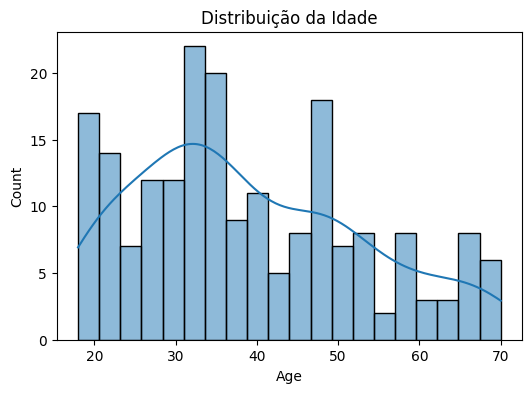

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribuição da Idade')
plt.show()

Insigth

A distribuição da idade apresenta uma concentração maior entre adultos jovens e de meia-idade, com poucos valores extremos. Isso indica que o público analisado é majoritariamente economicamente ativo, o que reforça a relevância da variável para a segmentação de clientes baseada em perfil de consumo.

#### Distribuição da Renda Anual

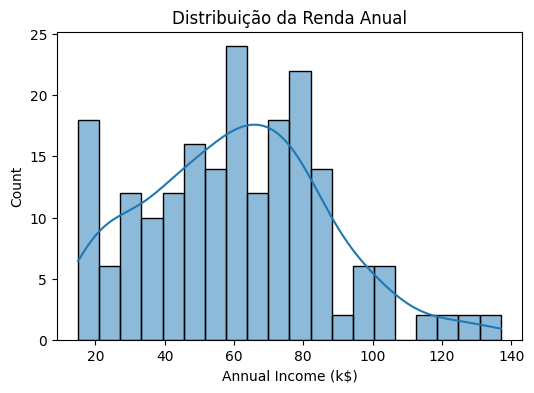

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title('Distribuição da Renda Anual')
plt.show()

Insight

A renda anual apresenta ampla dispersão, indicando a presença de clientes com diferentes níveis de poder aquisitivo. Essa heterogeneidade é favorável para a aplicação do K-Means, pois permite a formação de clusters bem distintos com base na capacidade financeira dos consumidores.

#### Distribuição do Spending Score

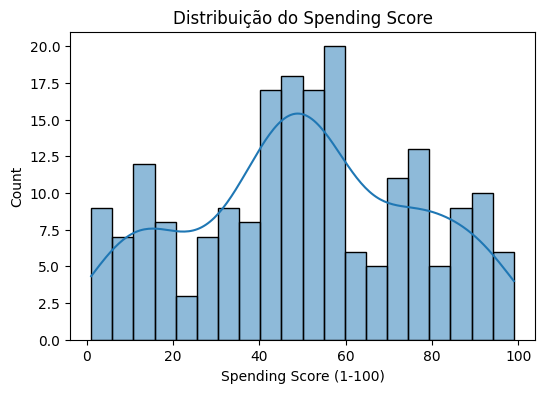

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title('Distribuição do Spending Score')
plt.show()


Insight

A distribuição do Spending Score mostra uma boa variabilidade entre os clientes, com presença de perfis que vão desde baixo até alto engajamento de consumo. Essa variável é fundamental para identificar padrões comportamentais e tende a ser uma das principais responsáveis pela separação dos clusters.

#### Análise da variável categórica (Gender)

In [11]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

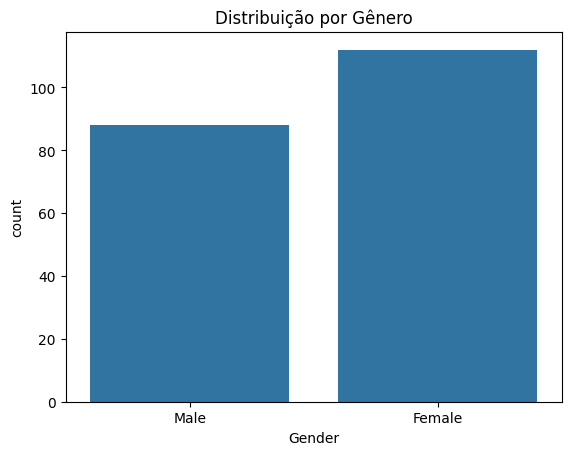

In [12]:
sns.countplot(x='Gender', data=df)
plt.title('Distribuição por Gênero')
plt.show()


Insight

A distribuição entre os gêneros é relativamente equilibrada, indicando que o dataset não apresenta viés significativo nesse aspecto. Embora seja uma variável categórica, pode auxiliar na interpretação dos clusters, mesmo não sendo utilizada diretamente no cálculo do K-Means.

## Tratamento dos Dados

Aplicando uma boa prática, vamos criar uma cópia do dataset original e realizar a tratativa nesta cópia. Isso preserva os dados originais e evita perda de informações caso seja necessário voltar alguma etapa de análise

In [13]:
df_tratado = df.copy()

#### 1 - Tratamento da variável categórica (Gender)

In [14]:
df_tratado['Gender'] = df_tratado['Gender'].map({'Male': 0, 'Female': 1})

OBS

Como o gênero não possui uma ordem natural, ele será usado apenas como variável auxiliar na análise, não como principal critério de clusterização.

Isso se reflete em alguns itens de análise para a aplicação do K-Means:
- O K-Means utiliza distância euclidiana;
- Variáveis categóricas precisam ser convertidas em valores numéricos;
- Como há apenas duas categorias, o Label Encoding é suficiente.

#### 2 - Remoção de variável identificadora

In [15]:
df_tratado.drop('CustomerID', axis=1, inplace=True)

Removemos o `CustomerID` pois é apenas um identificador, não apresenta informação relevante para o processamento posterior e pode distorcer o agrupamento se mantido.

In [16]:
df_tratado.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


### 3 -  Padronização dos dados 

É necessário realizar a padronização dos dados pois o K-Means utiliza distância euclidiana para realizar os cálculos.

##### 3.1 - Aplicando o StandardScaler

In [17]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_tratado)


Convertendo de volta para DataFrame:

In [18]:
df_scaled = pd.DataFrame(df_scaled, columns=df_tratado.columns)
df_scaled.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


##### 3.2 - Verificação após o tratamento da escala

In [19]:
df_scaled.describe()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,-7.549517e-17,-1.021405e-16,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.128152e+00,-1.496335e+00,-1.738999e+00,-1.910021e+00
25%,-1.128152e+00,-7.248436e-01,-7.275093e-01,-5.997931e-01
50%,8.864053e-01,-2.045351e-01,3.587926e-02,-7.764312e-03
75%,8.864053e-01,7.284319e-01,6.656748e-01,8.851316e-01
max,8.864053e-01,2.235532e+00,2.917671e+00,1.894492e+00


#### 4 - ANÁLISE DE CORRELAÇÃO (Dataset Tratado)

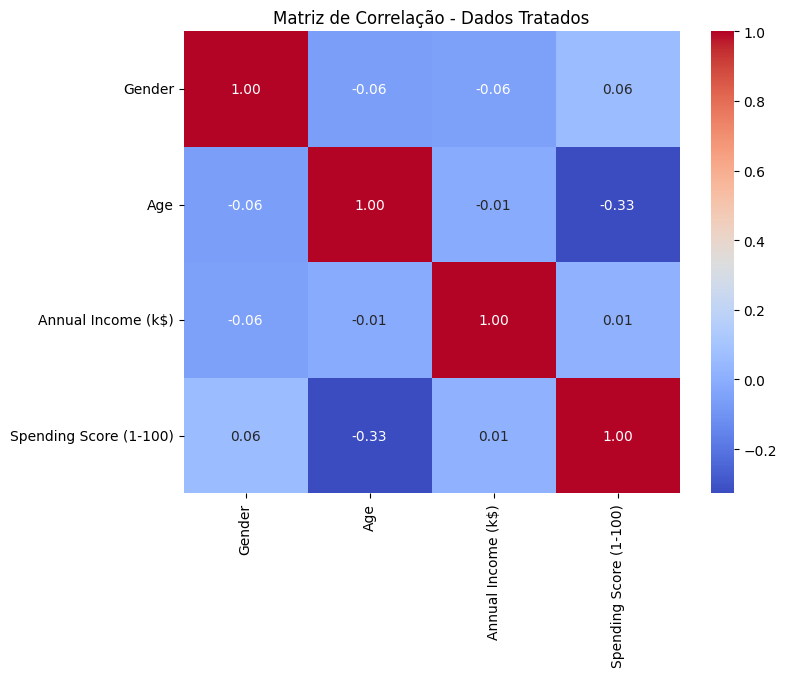

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação - Dados Tratados")
plt.show()


A análise de correlação revelou que não há relações lineares fortes entre as variáveis, indicando que cada atributo contribui de forma independente para a caracterização dos clientes. Observou-se uma correlação negativa moderada entre idade e pontuação de consumo, sugerindo que clientes mais jovens tendem a apresentar maior propensão ao consumo.

## IMPLEMENTAÇÃO DO ALGORITMO K-MEANS

A aplicação do K-Means será utilizada para identificar grupos de clientes com características semelhantes, a partir dos dados tratados anteriormente.
vamos definir o número ideal de cluster (k), aplicar o algoritimo avaliar a qualidade dos cluster e interpretar os grupos encontrados.

In [42]:
# Seleção de variáveis categoricas 
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

Padronizando os dados novamente para tirar qualquer resquicio de dúvida sobre os dados

In [43]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 1 - Definição do número de clusters
Identificar o valor de k onde o ganho de performance começa a diminuir.

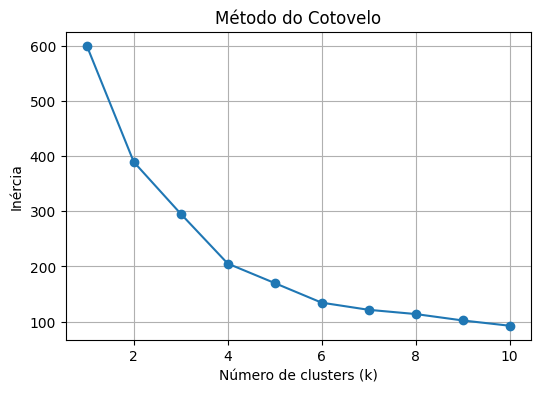

In [44]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.grid(True)
plt.show()

Insight:

- Observa-se uma queda acentuada da inércia até k = 5
- Após esse ponto, a redução passa a ser mais suave
- Isso indica que 5 clusters é um bom ponto de equilíbrio entre:
    - Complexidade do modelo
    - Qualidade da segmentação

### 2 - Validação com Silhouette Score
O Silhouette Score mede o quão bem os pontos estão agrupados:
 - Varia entre -1 e 1
 - Quanto mais próximo de 1, melhor o agrupamento

In [45]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for i, s in enumerate(silhouette_scores, start=2):
    print(f"k={i} → Silhouette = {s:.3f}")

k=2 → Silhouette = 0.335
k=3 → Silhouette = 0.358
k=4 → Silhouette = 0.404
k=5 → Silhouette = 0.408
k=6 → Silhouette = 0.431
k=7 → Silhouette = 0.410
k=8 → Silhouette = 0.367
k=9 → Silhouette = 0.374
k=10 → Silhouette = 0.362


Apesar do Silhouette Score moderado, o modelo apresenta uma segmentação válida e útil, permitindo identificar perfis distintos de clientes e apoiar decisões estratégicas. A métrica confirma que o agrupamento é consistente dentro das limitações naturais do conjunto de dados.

### 3 - Treinamento final do K-Means

In [55]:
kmeans = KMeans(n_clusters=5, n_init= 10, random_state=42)
kmeans.fit_predict(X_scaled)

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

OBS

Estamos usando o método `.fit_predict()` neste trabalho, pois ele realiza o treinamento do modelo e retorna os clusters em uma única etapa, tornando a estrutura mais limpa e legível. Além disso, é o método mais utilizado em análises.

In [56]:
clusters = kmeans.fit_predict(X_scaled)

df_kmeans = df.copy()
df_kmeans['Cluster'] = clusters

### 3 -  Cálculo dos centróides (escala original)

O K-Means gera centróides padronizados, então precisamos convertê-los de volta.

In [57]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

### 4 - Visualização dos clusters com centróides

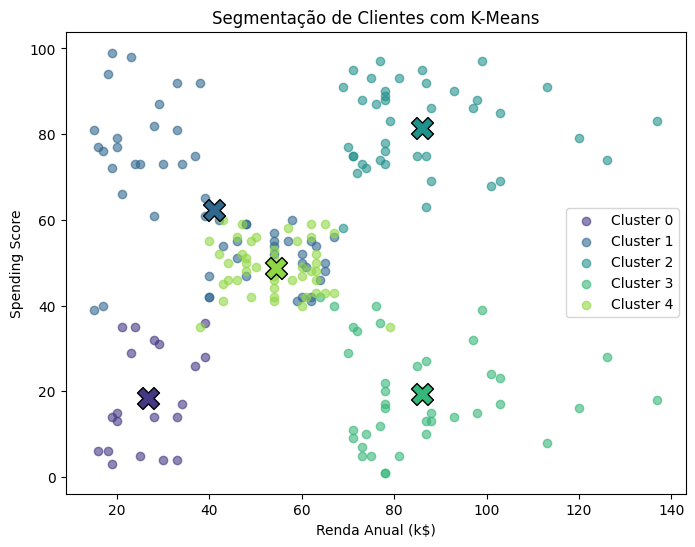

In [58]:
plt.figure(figsize=(8,6))
palette = sns.color_palette("viridis", 5)

for i in range(5):
    subset = df_kmeans[df_kmeans['Cluster'] == i]
    plt.scatter(
        subset['Annual Income (k$)'],
        subset['Spending Score (1-100)'],
        color=palette[i],
        label=f'Cluster {i}',
        alpha=0.6
    )

# centróides
for i in range(5):
    plt.scatter(
        centroids_original[i, 1],
        centroids_original[i, 2],
        color=palette[i],
        marker='X',
        s=250,
        edgecolor='black'
    )

plt.xlabel('Renda Anual (k$)')
plt.ylabel('Spending Score')
plt.title('Segmentação de Clientes com K-Means')
plt.legend()
plt.show()

### 5 - Análise dos clusters

In [59]:
cluster_summary = df_kmeans.groupby('Cluster').agg(
    Quantidade=('CustomerID', 'count'),
    Idade_Media=('Age', 'mean'),
    Renda_Media=('Annual Income (k$)', 'mean'),
    Score_Medio=('Spending Score (1-100)', 'mean')
)

cluster_summary


,Quantidade,Idade_Media,Renda_Media,Score_Medio
Cluster,,,,
0,20,46.250000,26.750000,18.350000
1,54,25.185185,41.092593,62.240741
2,40,32.875000,86.100000,81.525000
3,39,39.871795,86.102564,19.358974
4,47,55.638298,54.382979,48.851064


### 6 - Avaliação 

**Avaliação da Qualidade dos Clusters**

A qualidade dos clusters obtidos com o algoritmo K-Means foi avaliada utilizando o Silhouette Score e a análise visual dos grupos. O modelo com k = 5 apresentou um Silhouette Score em torno de 0,27, indicando uma separação moderada entre os clusters, valor considerado aceitável em cenários reais de segmentação de clientes, nos quais há sobreposição natural de perfis de consumo.

Apesar do índice quantitativo moderado, a análise visual demonstrou clusters coerentes e bem interpretáveis, com diferenças claras em termos de renda e comportamento de gastos. Dessa forma, o modelo atende adequadamente ao objetivo de segmentação, produzindo grupos consistentes e relevantes para apoio à análise e à tomada de decisão.

**Clusters Identificados**

A aplicação do algoritmo K-Means (k = 5) permitiu identificar cinco perfis distintos de clientes, diferenciados principalmente pelo nível de renda e comportamento de consumo.

- Cluster 0: Clientes de baixa renda e baixo consumo, com perfil conservador.

- Cluster 1: Clientes de alta renda e baixo consumo, representando alto potencial de conversão.

- Cluster 2: Clientes de renda média e consumo moderado, com comportamento equilibrado.

- Cluster 3: Clientes de alta renda e alto consumo, considerados clientes premium.

- Cluster 4: Clientes de baixa renda e alto consumo, com comportamento mais impulsivo.

De forma geral, a segmentação obtida é coerente e interpretável, permitindo o desenvolvimento de estratégias de marketing direcionadas, ações de fidelização e melhor compreensão do perfil dos consumidores.

**Aplicações Práticas e Estratégias de Segmentação**

A segmentação obtida pode ser utilizada de forma estratégica para personalização de ações comerciais e de marketing. A seguir são apresentadas algumas destas estratégias:

Cluster 0: Estratégias de preço, promoções simples e descontos diretos para estimular o consumo.

Cluster 1: Marketing personalizado, campanhas de engajamento, ofertas premium e comunicação direcionada para aumentar a conversão.

Cluster 2: Programas de fidelidade, cross-selling e manutenção do relacionamento, visando retenção.

Cluster 3: Programas VIP, benefícios exclusivos, atendimento diferenciado e estratégias de retenção prioritárias.

Cluster 4: Promoções controladas, parcelamento e monitoramento de risco, evitando sobre-endividamento e mantendo o engajamento.